# 05 – Visualisierungen: Tabellen-Relevanz-Analyse

Vergleich aller drei Methoden:
- **Regex** (Methode A): Zahlen-Overlap mit optimiertem Muster
- **spaCy** (Methode B): NER + Dependency-Score
- **LLM / Ollama** (Methode C): Semantische Bewertung via llama3.2


In [1]:
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

notebook_path = globals().get('__vsc_ipynb_file__')
NOTEBOOK_DIR = pathlib.Path(notebook_path).resolve().parent if notebook_path else pathlib.Path.cwd()

# CSVs laden
regex  = pd.read_csv(NOTEBOOK_DIR / 'regex_results.csv')
spacy  = pd.read_csv(NOTEBOOK_DIR / 'spacy_results.csv')
llm    = pd.read_csv(NOTEBOOK_DIR / 'llm_results.csv')

# Stil
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {
    'regex'  : '#2196F3',
    'ner'    : '#4CAF50',
    'dep'    : '#8BC34A',
    'spacy'  : '#388E3C',
    'llm'    : '#FF5722',
    'neutral': '#90A4AE',
}

print(f'Regex:  {len(regex)} Tabellen')
print(f'spaCy:  {len(spacy)} Tabellen')
print(f'LLM:    {len(llm)} Tabellen')


Regex:  266 Tabellen
spaCy:  327 Tabellen
LLM:    342 Tabellen


## Grafik 1 – Methoden-Vergleich: Durchschnittlicher Overlap-Score

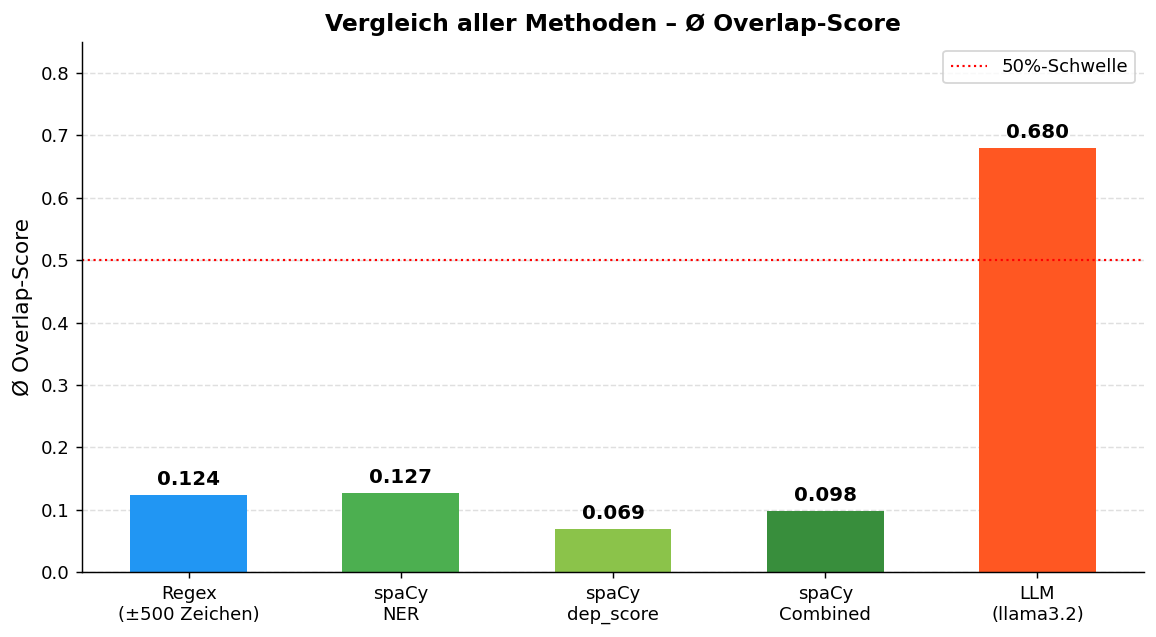

Gespeichert: plot1_methoden_vergleich.png


In [2]:
fig, ax = plt.subplots(figsize=(9, 5))

methoden = ['Regex\n(±500 Zeichen)', 'spaCy\nNER', 'spaCy\ndep_score', 'spaCy\nCombined', 'LLM\n(llama3.2)']
scores   = [
    regex['overlap'].mean(),
    spacy['ner_overlap'].mean(),
    spacy['dep_score'].mean(),
    spacy['combined'].mean(),
    llm['llm_score'].mean(),
]
farben = [COLORS['regex'], COLORS['ner'], COLORS['dep'], COLORS['spacy'], COLORS['llm']]

bars = ax.bar(methoden, scores, color=farben, width=0.55, zorder=2)
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)
ax.set_ylabel('Ø Overlap-Score', fontsize=12)
ax.set_title('Vergleich aller Methoden – Ø Overlap-Score', fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.85)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(0.5, color='red', linestyle=':', linewidth=1.2, label='50%-Schwelle')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / 'plot1_methoden_vergleich.png', bbox_inches='tight')
plt.show()
print('Gespeichert: plot1_methoden_vergleich.png')


## Grafik 2 – Score-Verteilung je Methode

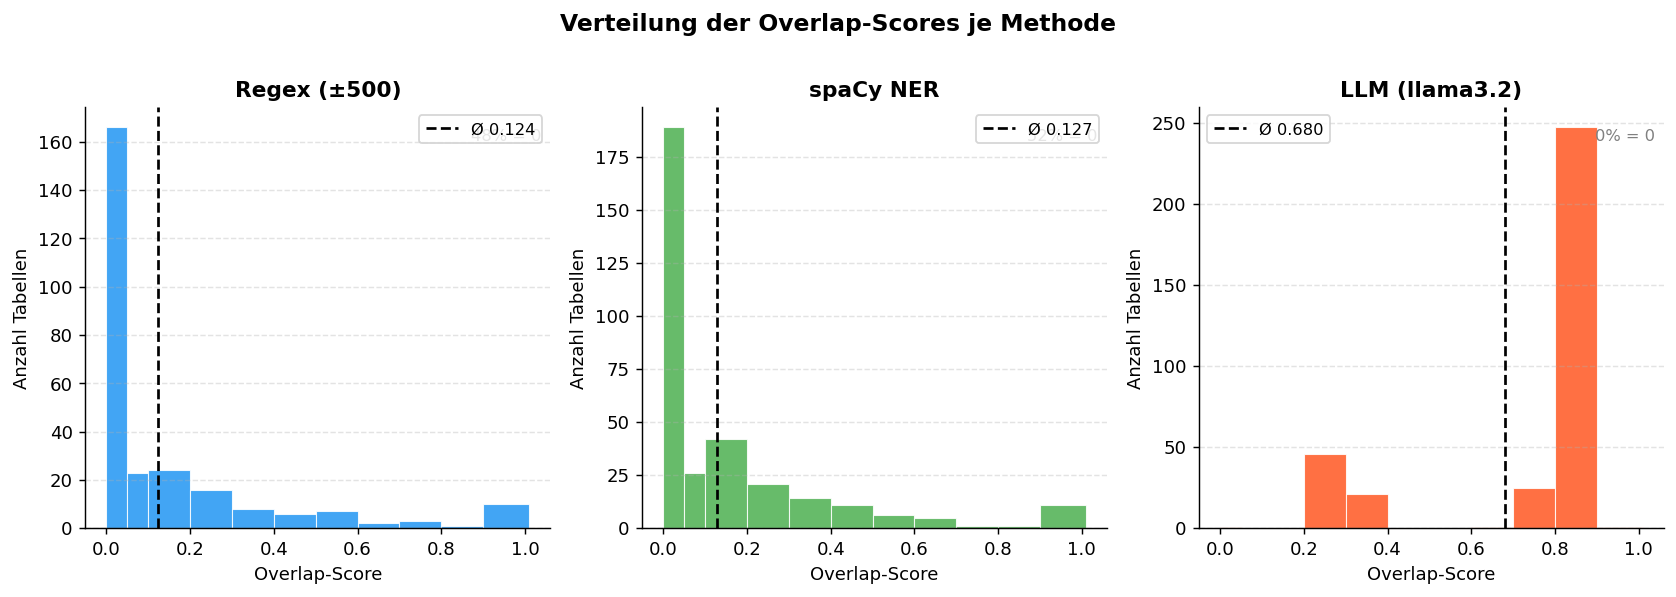

Gespeichert: plot2_score_verteilung.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=False)

datasets = [
    (regex['overlap'],       'Regex (±500)',     COLORS['regex']),
    (spacy['ner_overlap'],   'spaCy NER',        COLORS['ner']),
    (llm['llm_score'],       'LLM (llama3.2)',   COLORS['llm']),
]

for ax, (data, title, color) in zip(axes, datasets):
    bins = [0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.01]
    counts, edges = np.histogram(data.dropna(), bins=bins)
    ax.bar(edges[:-1], counts, width=np.diff(edges), color=color,
           alpha=0.85, align='edge', edgecolor='white', linewidth=0.6)
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Ø {data.mean():.3f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Overlap-Score')
    ax.set_ylabel('Anzahl Tabellen')
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    zero_pct = (data == 0).mean() * 100
    ax.text(0.98, 0.95, f'{zero_pct:.0f}% = 0', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='gray')

fig.suptitle('Verteilung der Overlap-Scores je Methode', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / 'plot2_score_verteilung.png', bbox_inches='tight')
plt.show()
print('Gespeichert: plot2_score_verteilung.png')


## Grafik 3 – Tabellen-Kategorien (Erstanalyse)

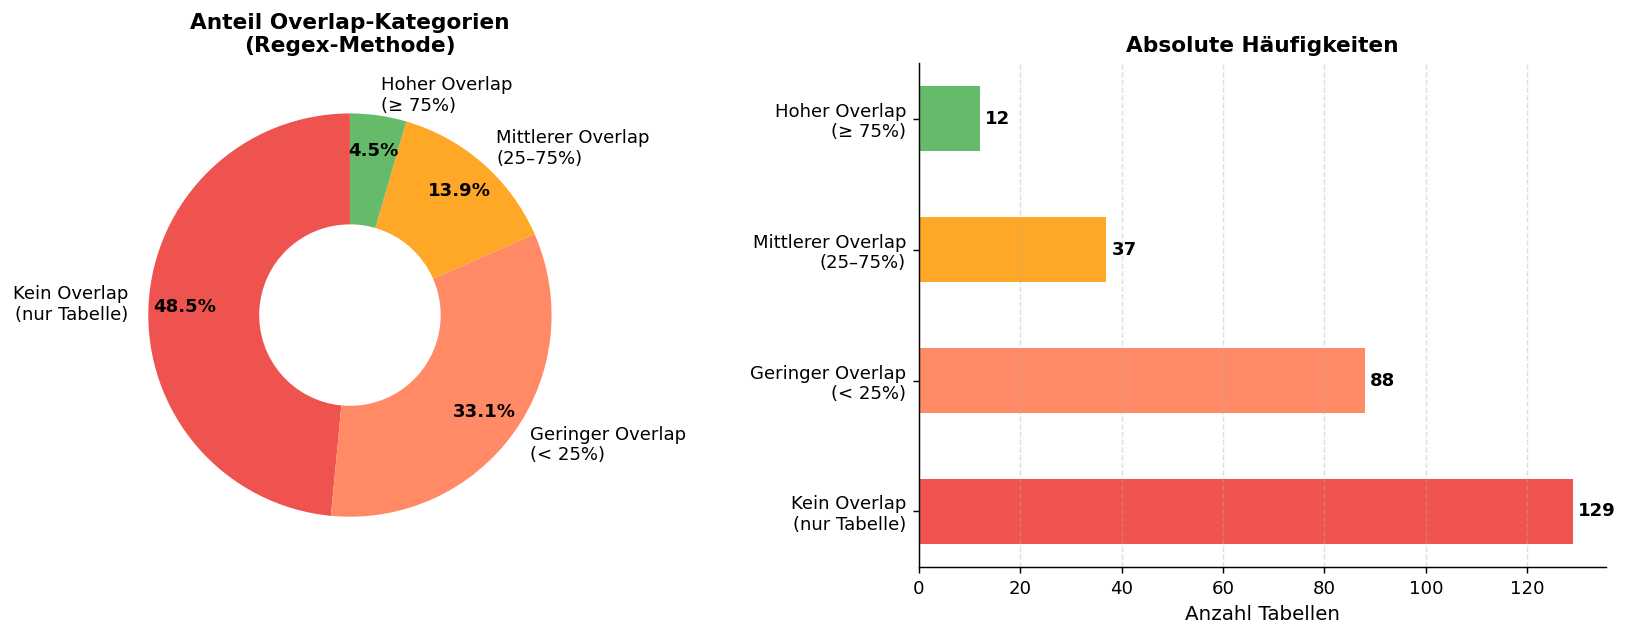

Gespeichert: plot3_kategorien.png


In [4]:
# Kategorisierung der Regex-Ergebnisse
def kategorisieren(score):
    if score == 0:      return 'Kein Overlap\n(nur Tabelle)'
    elif score < 0.25:  return 'Geringer Overlap\n(< 25%)'
    elif score < 0.75:  return 'Mittlerer Overlap\n(25–75%)'
    else:               return 'Hoher Overlap\n(≥ 75%)'

regex['kategorie'] = regex['overlap'].apply(kategorisieren)
kat_counts = regex['kategorie'].value_counts()

# Reihenfolge definieren
order = ['Kein Overlap\n(nur Tabelle)', 'Geringer Overlap\n(< 25%)',
         'Mittlerer Overlap\n(25–75%)', 'Hoher Overlap\n(≥ 75%)']
kat_counts = kat_counts.reindex([k for k in order if k in kat_counts.index])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Donut-Chart
farben_kat = ['#EF5350', '#FF8A65', '#FFA726', '#66BB6A']
wedges, texts, autotexts = axes[0].pie(
    kat_counts.values, labels=kat_counts.index,
    colors=farben_kat[:len(kat_counts)],
    autopct='%1.1f%%', pctdistance=0.82,
    startangle=90, wedgeprops=dict(width=0.55)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
axes[0].set_title('Anteil Overlap-Kategorien\n(Regex-Methode)', fontsize=12, fontweight='bold')

# Balken rechts: Absolute Zahlen
bars = axes[1].barh(kat_counts.index, kat_counts.values,
                    color=farben_kat[:len(kat_counts)], height=0.5)
axes[1].set_xlabel('Anzahl Tabellen', fontsize=11)
axes[1].set_title('Absolute Häufigkeiten', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', linestyle='--', alpha=0.4)
for bar, val in zip(bars, kat_counts.values):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / 'plot3_kategorien.png', bbox_inches='tight')
plt.show()
print('Gespeichert: plot3_kategorien.png')


## Grafik 4 – Regex: Einfluss der Fenstergröße

± 200: n=256, Ø=0.0676
± 500: n=256, Ø=0.1300
±1000: n=256, Ø=0.2439


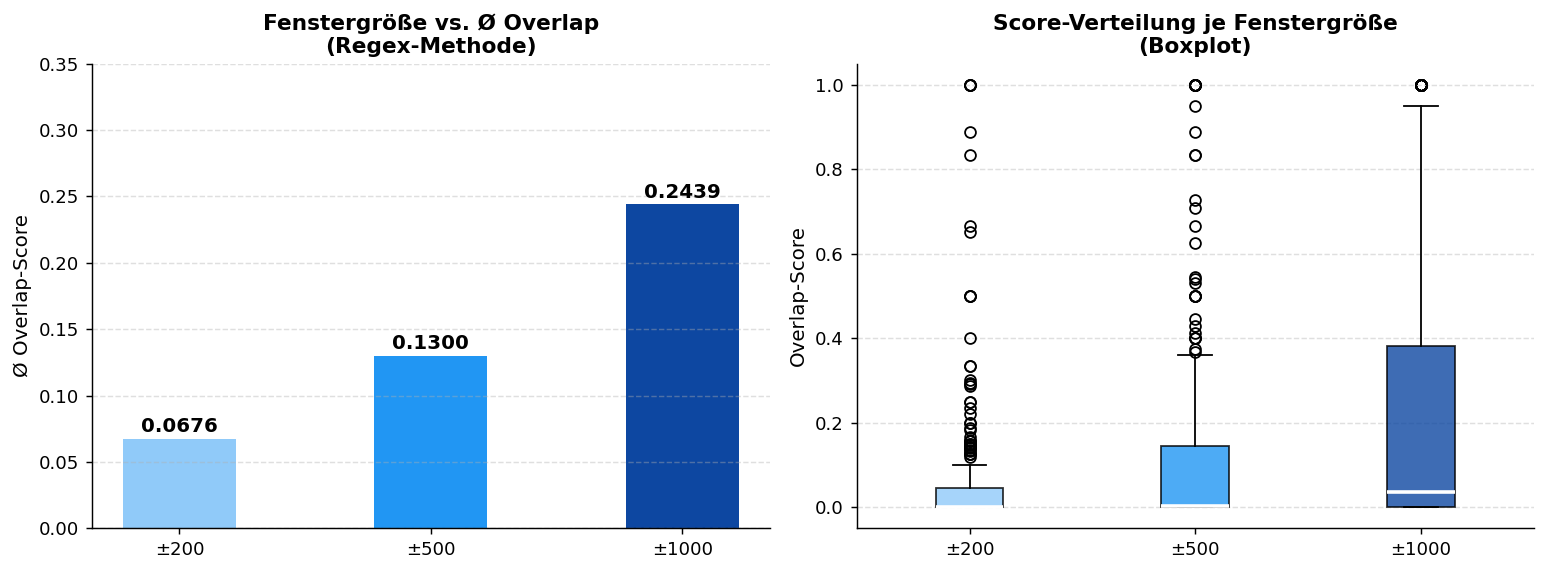

Gespeichert: plot4_fenstergroessen.png


In [5]:
import json, re, glob

# Fenstergrößen neu berechnen (aus JSON-Daten direkt)
import sys
sys.path.insert(0, str(NOTEBOOK_DIR))

# Hilfsfunktionen (dieselben wie in 02_regex.ipynb)
def clean_text(text):
    if not text: return ''
    text = re.sub(r'\[\d[\d,;\s\-]*\]', ' ', text)
    text = re.sub(r'\b(19|20)\d{2}\b', ' ', text)
    text = re.sub(r'\bFig\.?\s*\d+\b', ' ', text)
    text = re.sub(r'\bTable\s*\d+\b', ' ', text)
    text = re.sub(r'\bp\s*[<>=]\s*0\.\d+', ' PVAL ', text)
    return text

def normalize_number(s):
    s = s.strip()
    if re.match(r'^\d{1,3}(,\d{3})+$', s):
        s = s.replace(',', '')
    else:
        s = s.replace(',', '.')
    try: return str(round(float(s), 6))
    except: return s

def extract_numbers(text):
    text = clean_text(text)
    exact = set()
    for m in re.finditer(r'\d+\.?\d*[eE][+-]?\d+', text):
        exact.add(normalize_number(m.group()))
    for m in re.finditer(r'\d+[.,]\d+\s*[%µa-zA-Z]{1,4}\b', text):
        val = m.group().replace(' ','')
        num = re.match(r'[\d.,]+', val).group()
        exact.add(normalize_number(num) + val[len(num):].lower())
    for m in re.finditer(r'(?:n\s*=\s*)?(\d+)\s*([%µg]|mg|ml|kg|mm|cm|kb|mb|bp)\b', text):
        exact.add(normalize_number(m.group(1)) + m.group(2).lower())
    for m in re.finditer(r'\b\d+[.,]\d+\b', text):
        exact.add(normalize_number(m.group()))
    fuzzy = set()
    for v in exact:
        n = re.match(r'[\d.]+', v)
        if n:
            try: fuzzy.add(str(round(float(n.group()),1)) + v[n.end():])
            except: pass
    return exact, fuzzy

output_dir = NOTEBOOK_DIR / 'output'
json_files = sorted(output_dir.glob('*.json'))

window_means = {}
window_data  = {}

for win in [200, 500, 1000]:
    scores = []
    for fpath in json_files:
        with open(fpath, encoding='utf-8') as f:
            doc = json.load(f)
        fulltext = doc.get('text', '')
        year = (doc.get('metadata') or {}).get('preprint_date','')[:4]
        if not year: continue
        for tab in doc.get('tables', []):
            if not (tab.get('caption') or tab.get('name')): continue
            refs = [r for r in (tab.get('references') or []) if len(r) > 30]
            if not refs: continue
            raw = tab.get('content','{}')
            try:
                content = json.loads(raw) if isinstance(raw,str) else raw
                cells_txt = ' '.join(str(v) for row in content.get('data',[]) for v in row)
            except: continue
            te, tf = extract_numbers(cells_txt)
            if not te: continue
            best = 0.0
            for ref in refs:
                search = ref[:60].strip()
                idx = fulltext.find(search)
                if idx == -1: continue
                wt = fulltext[max(0,idx-win): idx+len(search)+win]
                we, wf = extract_numbers(wt)
                if not te: continue
                eh = len(te & we)
                fh = max(0, len(tf & wf) - eh)
                s = min((eh + 0.5*fh)/len(te), 1.0)
                if s > best: best = s
            scores.append(best)
    window_means[win] = sum(scores)/len(scores) if scores else 0
    window_data[win]  = scores
    print(f'±{win:>4}: n={len(scores)}, Ø={window_means[win]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Balken: Ø Overlap je Fenstergröße
wins = [200, 500, 1000]
means = [window_means[w] for w in wins]
bar_colors = ['#90CAF9', '#2196F3', '#0D47A1']
bars = axes[0].bar([f'±{w}' for w in wins], means, color=bar_colors, width=0.45)
axes[0].set_ylabel('Ø Overlap-Score', fontsize=11)
axes[0].set_title('Fenstergröße vs. Ø Overlap\n(Regex-Methode)', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 0.35)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
for bar, m in zip(bars, means):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{m:.4f}', ha='center', fontsize=11, fontweight='bold')

# Boxplot: Verteilung je Fenstergröße
bp = axes[1].boxplot([window_data[w] for w in wins],
                     labels=[f'±{w}' for w in wins],
                     patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], bar_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_ylabel('Overlap-Score', fontsize=11)
axes[1].set_title('Score-Verteilung je Fenstergröße\n(Boxplot)', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / 'plot4_fenstergroessen.png', bbox_inches='tight')
plt.show()
print('Gespeichert: plot4_fenstergroessen.png')


## Grafik 5 – Jahrestrend: Hat sich der Overlap-Score über die Jahre verändert?

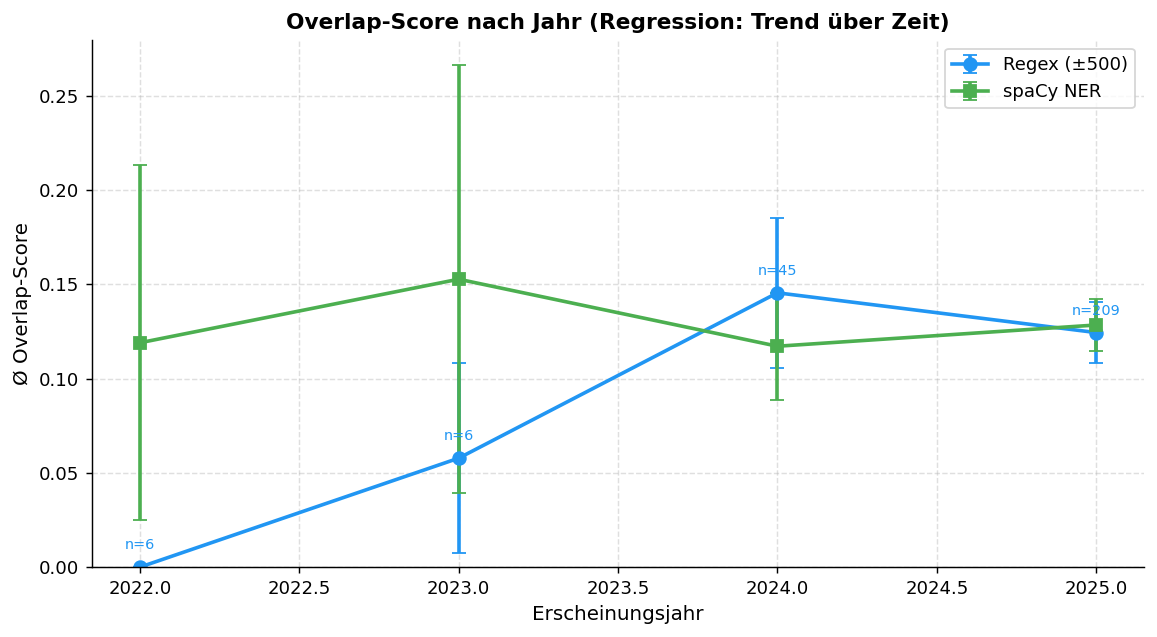

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

# Regex nach Jahr
reg_year = regex.groupby('year')['overlap'].agg(['mean','sem','count']).reset_index()
reg_year = reg_year[reg_year['year'] >= 2022]

# spaCy nach Jahr
spa_year = spacy.groupby('year')['ner_overlap'].agg(['mean','sem','count']).reset_index()
spa_year = spa_year[spa_year['year'] >= 2022]

ax.errorbar(reg_year['year'], reg_year['mean'], yerr=reg_year['sem'],
            color=COLORS['regex'], marker='o', linewidth=2, markersize=7,
            capsize=4, label='Regex (±500)')
ax.errorbar(spa_year['year'], spa_year['mean'], yerr=spa_year['sem'],
            color=COLORS['ner'], marker='s', linewidth=2, markersize=7,
            capsize=4, label='spaCy NER')

# Tabellenzahl als Beschriftung
for _, row in reg_year.iterrows():
    ax.annotate(f"n={int(row['count'])}", (row['year'], row['mean']),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8, color=COLORS['regex'])

ax.set_xlabel('Erscheinungsjahr', fontsize=11)
ax.set_ylabel('Ø Overlap-Score', fontsize=11)
ax.set_title('Overlap-Score nach Jahr (Regression: Trend über Zeit)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.4)
ax.set_ylim(0)

plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / 'plot5_jahrestrend.png', bbox_inches='tight')
plt.show()


## Grafik 6 – Gesamtübersicht: Was sagen die Methoden?

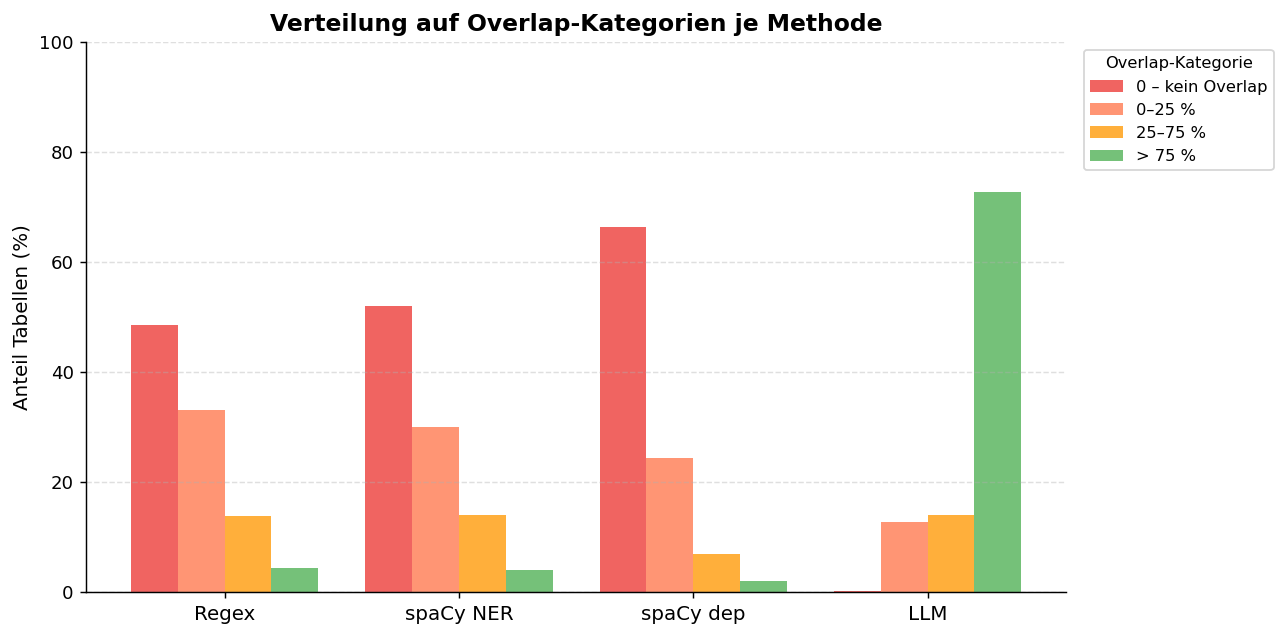

Gespeichert: plot6_gesamtuebersicht.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

# Für jede Methode: Anteil Tabellen in Kategorien
def score_to_cat(s):
    if s == 0:      return '0 – kein Overlap'
    elif s < 0.25:  return '0–25 %'
    elif s < 0.75:  return '25–75 %'
    else:           return '> 75 %'

methoden_dfs = {
    'Regex': regex['overlap'],
    'spaCy NER': spacy['ner_overlap'],
    'spaCy dep': spacy['dep_score'],
    'LLM': llm['llm_score'],
}

cat_order = ['0 – kein Overlap', '0–25 %', '25–75 %', '> 75 %']
cat_colors = ['#EF5350', '#FF8A65', '#FFA726', '#66BB6A']

x = np.arange(len(methoden_dfs))
width = 0.2
bottom = np.zeros(len(methoden_dfs))

for ci, (cat, color) in enumerate(zip(cat_order, cat_colors)):
    pcts = []
    for name, scores in methoden_dfs.items():
        cats = scores.dropna().apply(score_to_cat)
        pcts.append((cats == cat).mean() * 100)
    bars = ax.bar(x + ci*width - 1.5*width, pcts, width, label=cat, color=color, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(methoden_dfs.keys(), fontsize=11)
ax.set_ylabel('Anteil Tabellen (%)', fontsize=11)
ax.set_title('Verteilung auf Overlap-Kategorien je Methode', fontsize=13, fontweight='bold')
ax.legend(title='Overlap-Kategorie', fontsize=9, title_fontsize=9,
          bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / 'plot6_gesamtuebersicht.png', bbox_inches='tight')
plt.show()
print('Gespeichert: plot6_gesamtuebersicht.png')


## Zusammenfassung: Alle Ergebnisse auf einen Blick

In [8]:
summary = pd.DataFrame({
    'Methode': ['Regex (±200)', 'Regex (±500)', 'Regex (±1000)',
                'spaCy NER', 'spaCy dep_score', 'spaCy Combined', 'LLM (llama3.2)'],
    'Tabellen (n)': [len(regex), len(regex), len(regex),
                     len(spacy), len(spacy), len(spacy), len(llm)],
    'Ø Score': [
        window_means.get(200, float('nan')),
        regex['overlap'].mean(),
        window_means.get(1000, float('nan')),
        spacy['ner_overlap'].mean(),
        spacy['dep_score'].mean(),
        spacy['combined'].mean(),
        llm['llm_score'].mean(),
    ],
    'Median': [
        float('nan'), regex['overlap'].median(), float('nan'),
        spacy['ner_overlap'].median(), spacy['dep_score'].median(),
        spacy['combined'].median(), llm['llm_score'].median(),
    ],
    'Anteil Score=0': [
        float('nan'),
        f"{(regex['overlap']==0).mean()*100:.1f}%",
        float('nan'),
        f"{(spacy['ner_overlap']==0).mean()*100:.1f}%",
        f"{(spacy['dep_score']==0).mean()*100:.1f}%",
        f"{(spacy['combined']==0).mean()*100:.1f}%",
        f"{(llm['llm_score']==0).mean()*100:.1f}%",
    ],
})

summary['Ø Score'] = summary['Ø Score'].apply(lambda x: f'{x:.4f}' if pd.notna(x) else '–')
summary['Median']  = summary['Median'].apply(lambda x: f'{x:.4f}' if pd.notna(x) else '–')
print(summary.to_string(index=False))


        Methode  Tabellen (n) Ø Score Median Anteil Score=0
   Regex (±200)           266  0.0676      –            NaN
   Regex (±500)           266  0.1237 0.0029          48.5%
  Regex (±1000)           266  0.2439      –            NaN
      spaCy NER           327  0.1271 0.0000          52.0%
spaCy dep_score           327  0.0693 0.0000          66.4%
 spaCy Combined           327  0.0982 0.0250          41.6%
 LLM (llama3.2)           342  0.6798 0.8000           0.3%
